# 02 - Data Understanding

This notebook inspects the raw household power consumption dataset before cleaning or modeling. The goal is to understand the columns, actual local date range, missing values, and first consumption patterns.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "DataSet" / "household_power_consumption.csv"
DATA_PATH

WindowsPath('d:/dm-final-energy-omar/DataSet/household_power_consumption.csv')

## Load Raw Data

The raw CSV contains date and time columns plus power and sub-metering measurements. Missing values may appear as `?`, so they are registered as missing during loading.

In [3]:
raw_df = pd.read_csv(DATA_PATH, na_values=["?"], low_memory=False)
print("Raw shape:", raw_df.shape)
display(raw_df.head())

Raw shape: (1048575, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  str    
 1   Time                   1048575 non-null  str    
 2   Global_active_power    1044506 non-null  float64
 3   Global_reactive_power  1044506 non-null  float64
 4   Voltage                1044506 non-null  float64
 5   Global_intensity       1044506 non-null  float64
 6   Sub_metering_1         1044506 non-null  float64
 7   Sub_metering_2         1044506 non-null  float64
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(7), str(2)
memory usage: 88.5 MB


## Actual Local Date Range

The public source dataset may cover a longer period, but the project must report the date range that exists in the local CSV being analyzed.

In [5]:
datetime_series = pd.to_datetime(
    raw_df["Date"].astype(str) + " " + raw_df["Time"].astype(str),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce",
)

print("Start:", datetime_series.min())
print("End:", datetime_series.max())
print("Rows:", len(raw_df))

Start: 2006-12-16 17:24:00
End: 2008-12-13 21:38:00
Rows: 1048575


## Missing Values

Missing values are important because time-series models and clustering algorithms cannot work correctly with raw missing entries.

In [6]:
missing_summary = raw_df.isna().sum().sort_values(ascending=False)
display(missing_summary.to_frame("missing_count"))

,missing_count
Global_active_power,4069
Sub_metering_2,4069
Global_reactive_power,4069
Voltage,4069
Global_intensity,4069
Sub_metering_3,4069
Sub_metering_1,4069
Date,0
Time,0


In [7]:
numeric_columns = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

raw_numeric = raw_df[numeric_columns].apply(pd.to_numeric, errors="coerce")
display(raw_numeric.describe().T)

,count,mean,std,min,25%,50%,75%,max
Global_active_power,1044506.0,1.108202,1.129546,0.076,0.288,0.550,1.544,10.67
Global_reactive_power,1044506.0,0.118273,0.109506,0.000,0.000,0.098,0.186,1.39
Voltage,1044506.0,239.959803,3.284504,223.490,237.970,240.210,242.140,252.14
Global_intensity,1044506.0,4.718123,4.763588,0.200,1.200,2.400,6.400,46.40
Sub_metering_1,1044506.0,1.177451,6.321183,0.000,0.000,0.000,0.000,80.00
Sub_metering_2,1044506.0,1.475177,6.352703,0.000,0.000,0.000,1.000,78.00
Sub_metering_3,1044506.0,5.933837,8.210398,0.000,0.000,0.000,17.000,31.00


## First Visual Pattern

A small sample is plotted first to verify that the data behaves like an ordered time series before deeper preparation.

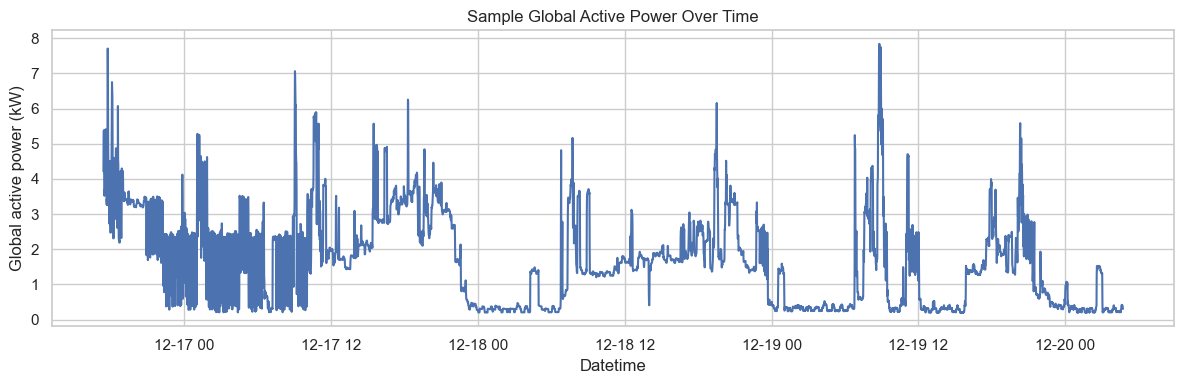

In [8]:
sample_df = raw_df.head(5000).copy()
sample_df["datetime"] = pd.to_datetime(
    sample_df["Date"].astype(str) + " " + sample_df["Time"].astype(str),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce",
)
sample_df["Global_active_power"] = pd.to_numeric(sample_df["Global_active_power"], errors="coerce")

plt.figure(figsize=(12, 4))
plt.plot(sample_df["datetime"], sample_df["Global_active_power"])
plt.title("Sample Global Active Power Over Time")
plt.xlabel("Datetime")
plt.ylabel("Global active power (kW)")
plt.tight_layout()
plt.show()